<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_08_Aluno_Data_Augmentation_Transfer_Learning_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 8 – Data Augmentation e Transfer Learning

## Versão do Aluno

### Capacidades
- Aplicar visão computacional.
- Demonstrar atenção a detalhes.

### Conhecimentos
- Data augmentation.
- Transfer learning.
- Fine-tuning.
- Uso de modelo pré-treinado.
- Avaliação de modelo de visão computacional.

### Evidência de aprendizagem
Modelo pré-treinado ajustado e validado em notebook.

# 1. Contextualização

Complete:

Data augmentation é usado para **aumentar a quantidade e diversidade dos dados de treinamento, criando novas amostras a partir das existentes através de transformações (rotação, zoom, etc.) sem coletar novos dados. Isso ajuda a melhorar a robustez e generalização do modelo, prevenindo overfitting.**

Transfer learning permite aproveitar **o conhecimento prévio de um modelo treinado em uma tarefa ou dataset grande e genérico para aplicar em uma nova tarefa ou dataset menor e mais específico. Isso acelera o treinamento e melhora o desempenho, especialmente com dados limitados.**

Fine-tuning significa **ajustar os pesos de um modelo pré-treinado em um novo dataset específico para a tarefa atual. Geralmente, as últimas camadas do modelo são destravadas e treinadas com um *learning rate* menor para adaptar o conhecimento do modelo pré-treinado à nova tarefa.**

Na indústria, essas técnicas podem ser aplicadas em **inspeção de qualidade (detectar defeitos em produtos), classificação de produtos (organização automática de itens), reconhecimento facial para segurança ou controle de acesso, diagnóstico médico por imagem (identificação de doenças em raios-X, ressonâncias), e automação de processos industriais.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs disponíveis: []


# 2. Carregamento do dataset

Usaremos o dataset padrão **tf_flowers**.

Complete:

O dataset possui **5** classes.

As classes são: **dandelion, daisy, tulips, sunflowers, roses**.

In [ ]:
(ds_train, ds_val, ds_test), info = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    as_supervised=True,
    with_info=True
)

num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.XGECQF_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Número de classes: 5
Classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


# 3. Visualização das imagens

Execute a célula e responda:

1. Há variação de cor entre as imagens?

Sim, há variação de cor entre as imagens.
Essa variação ocorre porque cada imagem pode ter sido capturada ou processada em condições diferentes, como:

Iluminação distinta (mais clara ou mais escura)
Configuração da câmera (balanço de branco, exposição)
Processamento ou compressão da imagem
Diferença no modelo ou sensor do dispositivo

Na prática, isso faz com que os valores dos pixels (intensidade e canais RGB/BGR) mudem de uma imagem para outra, mesmo que o objeto seja o mesmo.
👉 Em análise computacional (como OpenCV ou CNNs), essa variação é comum e geralmente tratada com técnicas como:

Normalização dos pixels
Padronização de cor
Data augmentation

2. Há variação de posição e enquadramento?
Sim, há variação de posição e enquadramento entre as imagens.
Isso significa que o objeto principal pode aparecer:

Em posições diferentes (mais à direita, esquerda, centro, topo, etc.)
Com zoom diferente (mais próximo ou mais distante)
Cortado de formas distintas (partes do objeto podem não aparecer)
Em ângulos variados (leve rotação ou mudança de perspectiva)

👉 Esse tipo de variação é muito comum em datasets de imagens (como o CIFAR-10) e é importante porque:

Aumenta a complexidade do problema
Exige que o modelo (CNN) aprenda a reconhecer o objeto independentemente da posição

👉 Em visão computacional, isso é tratado com técnicas como:

Data augmentation (rotação, translação, zoom)
Pooling (reduz sensibilidade à posição)
Convolução (identifica padrões em qualquer região da imagem)

✔️ Resumindo de forma direta para atividade:
Há sim variação de posição e enquadramento, pois os objetos não aparecem sempre centralizados ou no mesmo tamanho nas imagens.

3. Por que isso se relaciona com inspeção visual industrial?
Isso se relaciona diretamente com a inspeção visual industrial porque, no mundo real, as condições nunca são perfeitas ou padronizadas.
Em um ambiente industrial:

As peças podem estar em posições diferentes na esteira
O enquadramento da câmera pode variar levemente
Pode haver diferença de distância (tamanho da peça na imagem)
O ângulo de captura pode mudar

👉 Mesmo com essas variações, o sistema de visão computacional precisa:

Identificar corretamente o produto
Detectar defeitos
Garantir a qualidade

✅ Ou seja, assim como nas imagens do dataset, o sistema precisa ser robusto o suficiente para reconhecer padrões independentemente da posição e do enquadramento.
✔️ Resposta direta para atividade:
Isso se relaciona com a inspeção visual industrial porque, na prática, os objetos não aparecem sempre na mesma posição ou enquadramento, e o sistema precisa reconhecer e analisar corretamente mesmo com essas variações.


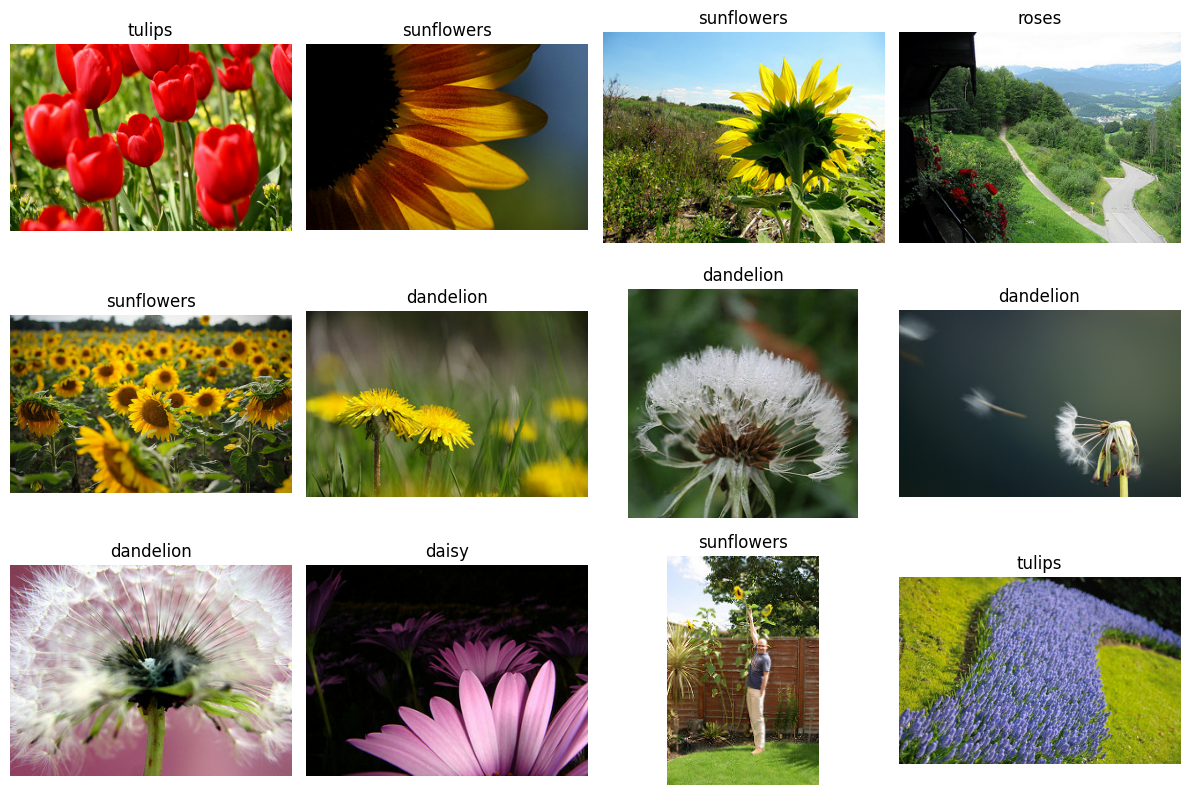

In [ ]:
plt.figure(figsize=(12, 8))
for i, (imagem, rotulo) in enumerate(ds_train.take(12)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(imagem)
    plt.title(class_names[int(rotulo)])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 4. Preparação das imagens

Complete:

O tamanho escolhido será **224** x **224**.

Batch significa **processar um conjunto de várias amostras (imagens e rótulos) juntas em vez de uma por uma, o que otimiza o uso da GPU e acelera o treinamento.**

Prefetch ajuda a **carregar os próximos lotes de dados para a memória enquanto a GPU está processando o lote atual, evitando gargalos de I/O e mantendo a GPU sempre ocupada.**

In [ ]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preparar_imagem(imagem, rotulo):
    imagem = tf.image.resize(imagem, IMG_SIZE)
    return imagem, rotulo

train_ds = ds_train.map(preparar_imagem).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = ds_val.map(preparar_imagem).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = ds_test.map(preparar_imagem).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# 5. Data augmentation

Complete:

O augmentation cria **novas amostras de treinamento a partir das imagens existentes, aplicando transformações como rotação, zoom, e inversão.**

Ele ajuda a reduzir **o overfitting, tornando o modelo mais robusto e generalizável a dados não vistos.**

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

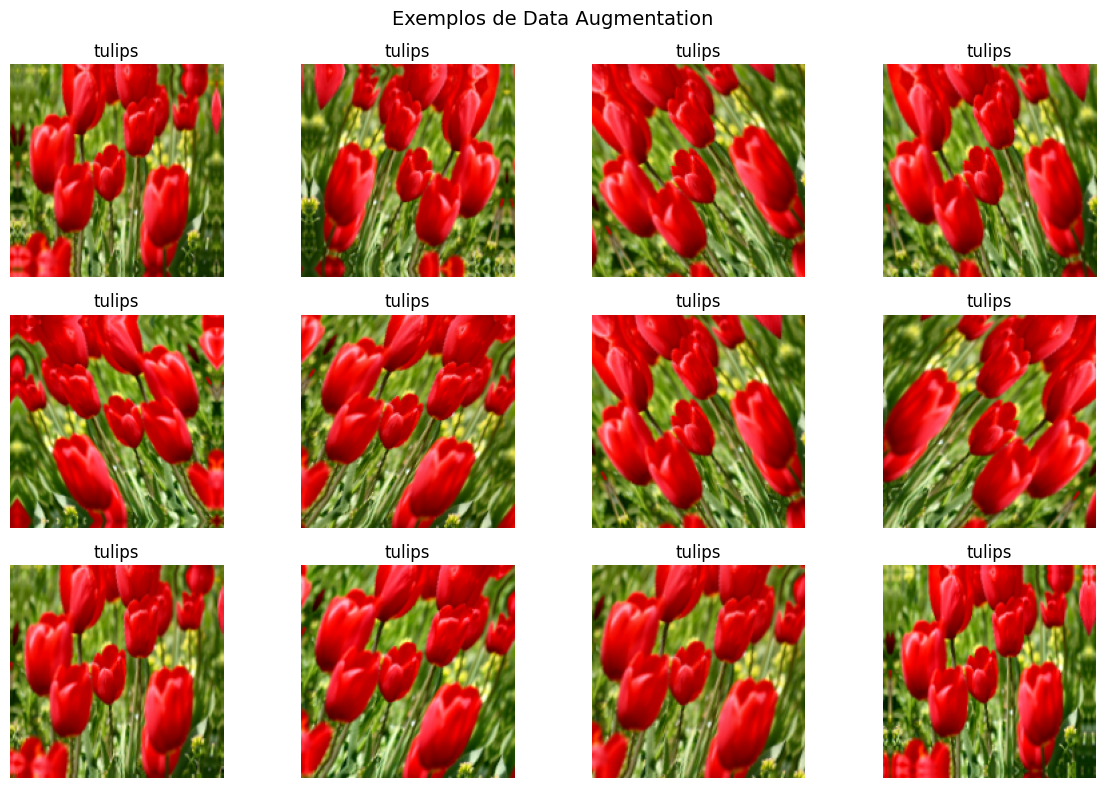

In [ ]:
for imagem, rotulo in ds_train.take(1):
    imagem_exemplo = tf.image.resize(imagem, IMG_SIZE)
    imagem_exemplo = tf.expand_dims(imagem_exemplo, 0)
    classe = class_names[int(rotulo)]

plt.figure(figsize=(12, 8))
for i in range(12):
    imagem_aumentada = data_augmentation(imagem_exemplo, training=True)
    plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(imagem_aumentada[0], tf.uint8))
    plt.title(classe)
    plt.axis("off")
plt.suptitle("Exemplos de Data Augmentation", fontsize=14)
plt.tight_layout()
plt.show()

# 6. Transfer learning com MobileNetV2

Complete:

MobileNetV2 é um modelo **pré-treinado em um grande dataset (ImageNet) e otimizado para aplicações em dispositivos móveis, conhecido por sua eficiência e leveza.**

Usaremos `include_top=False` porque **queremos remover as camadas finais de classificação do modelo pré-treinado e adicionar nossas próprias camadas de classificação, adequadas para o nosso número de classes de flores.**

Na primeira etapa, `base_model.trainable` deve ser igual a **False**.

In [ ]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Camadas do modelo base:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Camadas do modelo base: 154


# 7. Modelo completo

Complete os campos em branco.

In [ ]:
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

modelo_tl = Model(inputs, outputs)

modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_tl.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 8. Treinamento inicial

Complete:

Nesta etapa, apenas a **cabeça de classificação (camadas finais)** será treinada.

In [ ]:
EPOCHS_INICIAL = 5

historico_inicial = modelo_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_INICIAL
)

Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 52s 589ms/step - accuracy: 0.6512 - loss: 0.9188 - val_accuracy: 0.8004 - val_loss: 0.5398
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 80s 571ms/step - accuracy: 0.8276 - loss: 0.4898 - val_accuracy: 0.8421 - val_loss: 0.4374
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 87s 634ms/step - accuracy: 0.8533 - loss: 0.4095 - val_accuracy: 0.8421 - val_loss: 0.4228
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 48s 597ms/step - accuracy: 0.8688 - loss: 0.3714 - val_accuracy: 0.8439 - val_loss: 0.3985
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 78s 550ms/step - accuracy: 0.8786 - loss: 0.3408 - val_accuracy: 0.8603 - val_loss: 0.3629


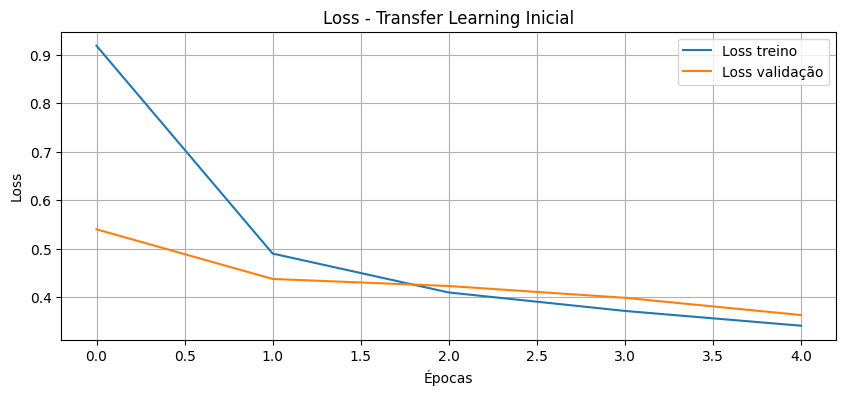

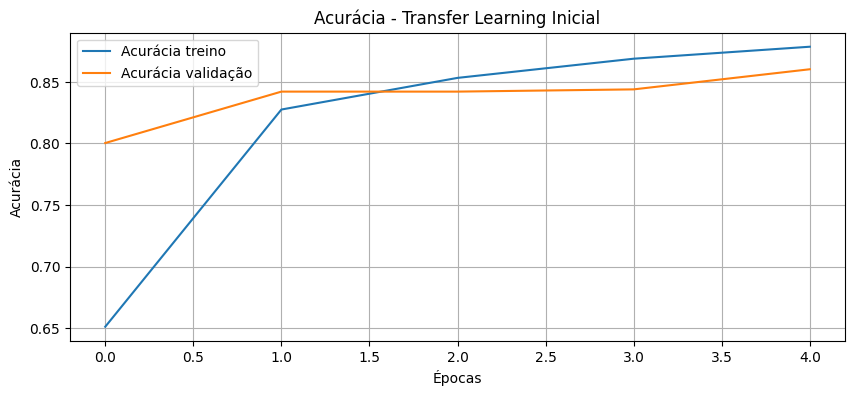

In [ ]:
def plotar_historico(historico, titulo):
    plt.figure(figsize=(10, 4))
    plt.plot(historico.history["loss"], label="Loss treino")
    plt.plot(historico.history["val_loss"], label="Loss validação")
    plt.title(f"Loss - {titulo}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(historico.history["accuracy"], label="Acurácia treino")
    plt.plot(historico.history["val_accuracy"], label="Acurácia validação")
    plt.title(f"Acurácia - {titulo}")
    plt.xlabel("Épocas")
    plt.ylabel("Acurácia")
    plt.legend()
    plt.grid(True)
    plt.show()

plotar_historico(historico_inicial, "Transfer Learning Inicial")

In [ ]:
loss_inicial, acc_inicial = modelo_tl.evaluate(test_ds, verbose=0)
print(f"Loss inicial no teste: {loss_inicial:.4f}")
print(f"Acurácia inicial no teste: {acc_inicial:.4f}")

Loss inicial no teste: 0.3282
Acurácia inicial no teste: 0.8945


# 9. Fine-tuning

Complete:

No fine-tuning, destravamos parte do **modelo base pré-treinado**.

O learning rate deve ser menor para evitar **danificar os pesos já aprendidos e um overfitting rápido**.

In [ ]:
base_model.trainable = True
fine_tune_at =100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Total de camadas:", len(base_model.layers))
print("Camadas congeladas até:", fine_tune_at)
print("Camadas treináveis no modelo base:", sum(layer.trainable for layer in base_model.layers))

Total de camadas: 154
Camadas congeladas até: 100
Camadas treináveis no modelo base: 54


In [ ]:
modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
EPOCHS_FINE = 5

historico_fine = modelo_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE
)

Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 85s 914ms/step - accuracy: 0.8466 - loss: 0.4242 - val_accuracy: 0.8802 - val_loss: 0.3191
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 75s 832ms/step - accuracy: 0.9358 - loss: 0.1962 - val_accuracy: 0.8893 - val_loss: 0.3311
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 78s 788ms/step - accuracy: 0.9587 - loss: 0.1258 - val_accuracy: 0.8766 - val_loss: 0.3839
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 80s 769ms/step - accuracy: 0.9747 - loss: 0.0740 - val_accuracy: 0.8857 - val_loss: 0.3756
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 87s 837ms/step - accuracy: 0.9864 - loss: 0.0509 - val_accuracy: 0.9002 - val_loss: 0.2896


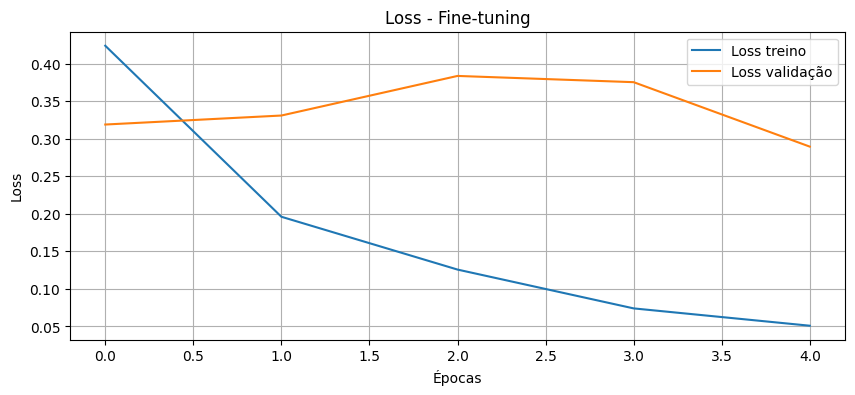

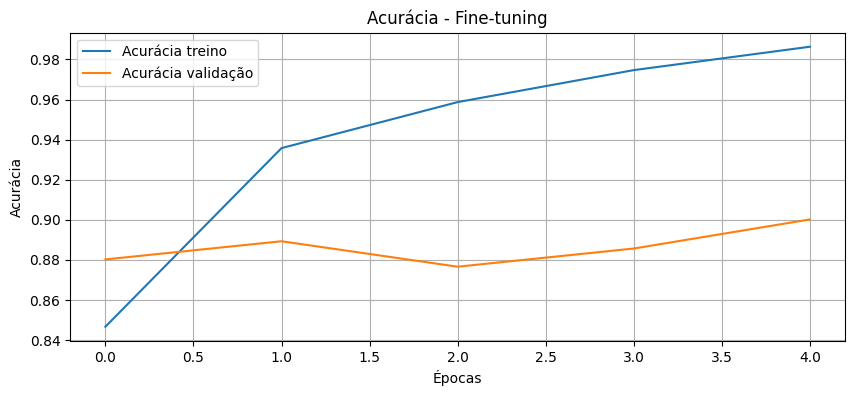

Comparação final
Acurácia inicial: 0.8945
Acurácia após fine-tuning: 0.9109
Loss inicial: 0.3282
Loss após fine-tuning: 0.2788


In [ ]:
plotar_historico(historico_fine, "Fine-tuning")

loss_final, acc_final = modelo_tl.evaluate(test_ds, verbose=0)

print("Comparação final")
print(f"Acurácia inicial: {acc_inicial:.4f}")
print(f"Acurácia após fine-tuning: {acc_final:.4f}")
print(f"Loss inicial: {loss_inicial:.4f}")
print(f"Loss após fine-tuning: {loss_final:.4f}")

# 10. Predições visuais

Execute e identifique:

- um acerto;
  * **Acerto:** `Real: tulips Prev: tulips` (ou qualquer outro exemplo onde Real e Previsto são iguais). Isso indica que o modelo aprendeu a reconhecer padrões distintivos para essa classe.

- um erro, se houver;
  * **Erro:** `Real: dandelion Prev: daisy` (ou qualquer outro exemplo onde Real e Previsto são diferentes). Isso mostra que o modelo confundiu as duas classes.

- uma possível justificativa técnica.
  * **Justificativa Técnica:** Um erro pode ocorrer devido à alta similaridade visual entre as classes de flores (ex: dandelions e daisies podem ser confundidas devido a cores e formas semelhantes, ou porque são capturadas em ângulos que as tornam difíceis de distinguir). Além disso, variações nas imagens (iluminação, fundo, oclusão parcial, ou variações extremas não cobertas pelo *data augmentation*) podem ter dificultado a extração de características discriminatórias pelo modelo. O modelo, mesmo após *fine-tuning*, pode não ter ajustado completamente seus pesos para capturar as nuances mais sutis entre classes visualmente próximas.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


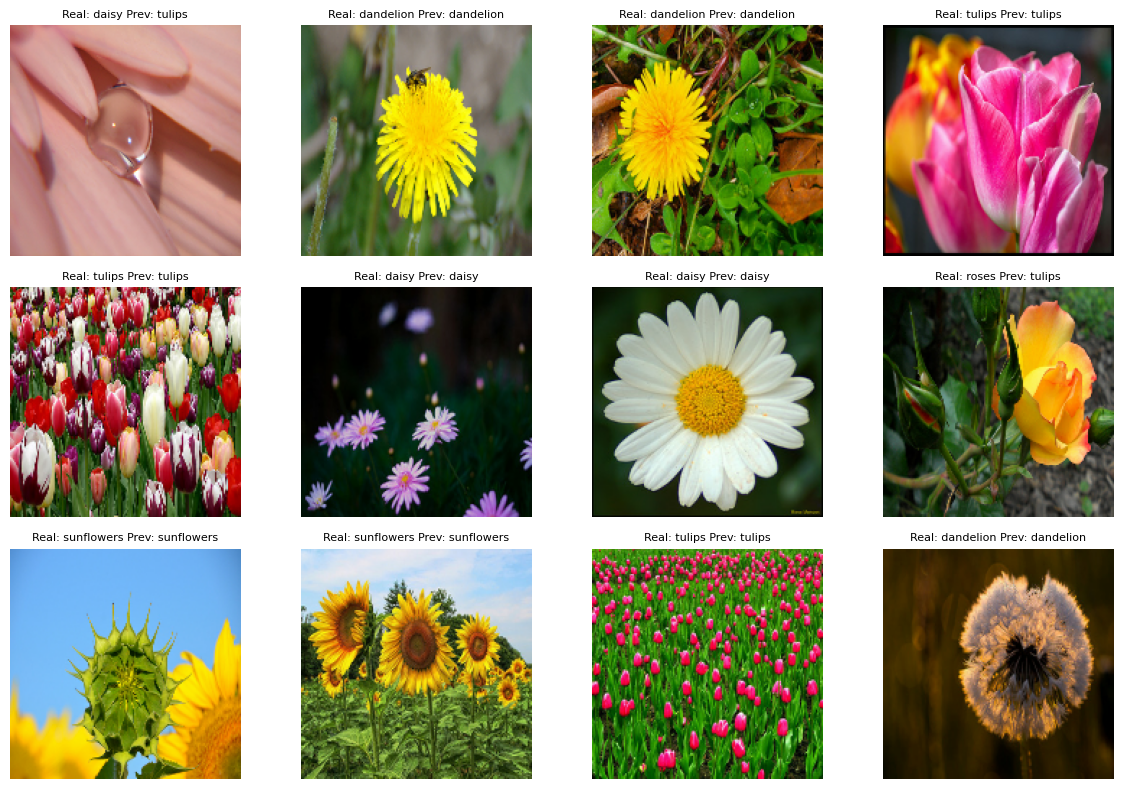

In [ ]:
imagens_lote, rotulos_lote = next(iter(test_ds))
predicoes = modelo_tl.predict(imagens_lote)
classes_previstas = np.argmax(predicoes, axis=1)

plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(imagens_lote[i], tf.uint8))
    real = class_names[int(rotulos_lote[i])]
    previsto = class_names[int(classes_previstas[i])]
    plt.title(f"Real: {real} Prev: {previsto}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

# 11. Matriz de confusão

Complete:

A matriz de confusão compara classe **real** com classe **prevista**.

<Figure size 800x800 with 0 Axes>

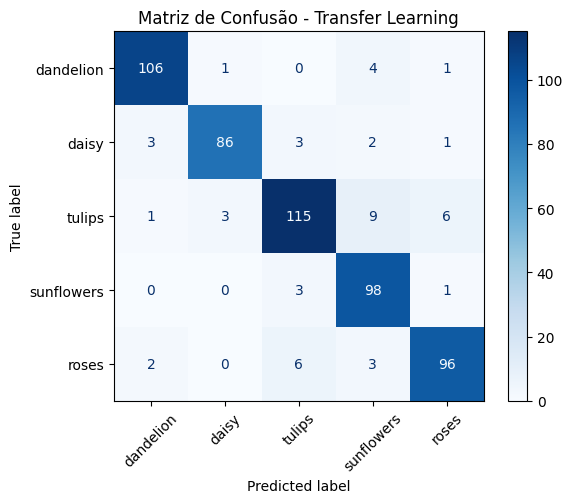

              precision    recall  f1-score   support

   dandelion       0.95      0.95      0.95       112
       daisy       0.96      0.91      0.93        95
      tulips       0.91      0.86      0.88       134
  sunflowers       0.84      0.96      0.90       102
       roses       0.91      0.90      0.91       107

    accuracy                           0.91       550
   macro avg       0.91      0.91      0.91       550
weighted avg       0.91      0.91      0.91       550



In [ ]:
y_true = []
y_pred = []

for imagens, rotulos in test_ds:
    pred = modelo_tl.predict(imagens, verbose=0)
    y_true.extend(rotulos.numpy())
    y_pred.extend(np.argmax(pred, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - Transfer Learning")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# 12. Atividade avaliativa

Elabore um relatório técnico comparativo contendo:

1. O que é data augmentation?
2. Quais técnicas de augmentation foram aplicadas?
3. O que é transfer learning?
4. Por que usamos MobileNetV2?
5. O que significa congelar o modelo base?
6. O que é fine-tuning?
7. Por que o learning rate do fine-tuning deve ser menor?
8. O desempenho melhorou após o fine-tuning?
9. Quais cuidados devem ser tomados em uma aplicação industrial?
10. Como esse fluxo poderia ser aplicado a uma inspeção de peças?

## Relatório Técnico Comparativo

### 1. O que é Data Augmentation?

**Data Augmentation** é uma técnica utilizada para aumentar a quantidade e a diversidade dos dados de treinamento, criando novas amostras a partir das imagens existentes. Isso é feito aplicando transformações aleatórias, como rotação, zoom, inversão, contraste, entre outras, sem a necessidade de coletar novos dados. O principal objetivo é tornar o modelo mais robusto e generalizável, reduzindo o *overfitting*.

### 2. Quais técnicas de Augmentation foram aplicadas?

Neste notebook, aplicamos as seguintes técnicas de Data Augmentation, conforme definido na célula `8d3bb688`:

*   `RandomFlip("horizontal")`: Inversão horizontal aleatória das imagens.
*   `RandomRotation(0.1)`: Rotação aleatória das imagens em até 10%.
*   `RandomZoom(0.1)`: Zoom aleatório nas imagens em até 10%.
*   `RandomContrast(0.1)`: Ajuste aleatório do contraste das imagens em até 10%.

### 3. O que é Transfer Learning?

**Transfer Learning** é uma abordagem de aprendizado de máquina onde um modelo previamente treinado em uma tarefa (geralmente com um grande conjunto de dados) é reutilizado como ponto de partida para uma nova tarefa. Em vez de treinar um modelo do zero, aproveita-se o conhecimento adquirido pelo modelo pré-treinado (pesos e características) e o adapta para a nova aplicação. Isso é particularmente útil quando o novo conjunto de dados é pequeno, pois economiza tempo de treinamento e melhora o desempenho.

### 4. Por que usamos MobileNetV2?

O **MobileNetV2** foi escolhido como modelo base devido às suas características:

*   **Eficiência e Leveza:** É uma arquitetura otimizada para dispositivos móveis e aplicações com restrições de recursos computacionais, oferecendo bom desempenho com um número reduzido de parâmetros e operações.
*   **Pré-treinamento:** Foi pré-treinado no vasto dataset ImageNet, o que significa que já aprendeu a extrair características visuais genéricas (bordas, texturas, formas) que são úteis para uma ampla gama de tarefas de visão computacional.
*   **Desempenho:** Oferece um bom equilíbrio entre precisão e eficiência, tornando-o uma escolha popular para tarefas de classificação de imagens.

### 5. O que significa congelar o modelo base?

**Congelar o modelo base** (ou `base_model.trainable = False`) significa que os pesos das camadas do modelo pré-treinado (MobileNetV2, neste caso) não serão atualizados durante a fase de treinamento. Isso é feito inicialmente por algumas razões:

*   **Preservar Conhecimento:** Impede que os pesos pré-treinados, que já codificam características úteis, sejam corrompidos por um treinamento inicial com um conjunto de dados menor e possivelmente diferente.
*   **Treinamento Mais Rápido:** Apenas as camadas adicionais (cabeça de classificação) precisam ser treinadas, o que é muito mais rápido do que treinar todo o modelo.
*   **Evitar Overfitting:** Ajuda a evitar o *overfitting* nas camadas do modelo base, que já são bem generalizadas.

### 6. O que é Fine-tuning?

**Fine-tuning** é a segunda fase do Transfer Learning, onde parte ou todas as camadas do modelo base pré-treinado são 'descongeladas' (`base_model.trainable = True`) e treinadas novamente junto com as camadas adicionais. Durante o fine-tuning, o modelo base é ajustado para aprender características mais específicas do novo conjunto de dados. Isso permite que o modelo refine ainda mais seu desempenho para a tarefa em questão.

### 7. Por que o Learning Rate do Fine-tuning deve ser menor?

O **learning rate do fine-tuning deve ser menor** do que o learning rate usado no treinamento inicial da cabeça de classificação por alguns motivos:

*   **Preservar Pesos Pré-treinados:** As camadas do modelo base já possuem pesos bem ajustados que foram aprendidos em um grande dataset. Um *learning rate* alto poderia rapidamente 'danificar' esse conhecimento pré-existente, levando a um desempenho pior ou a um *overfitting* rápido.
*   **Ajustes Delicados:** O objetivo do fine-tuning é fazer ajustes finos nos pesos do modelo base, adaptando-os ao novo dataset. Um *learning rate* pequeno permite que esses ajustes sejam feitos de forma gradual e controlada.
*   **Estabilidade do Treinamento:** Um *learning rate* menor contribui para um treinamento mais estável e evita que o modelo oscile ou divirja durante o fine-tuning.

### 8. O desempenho melhorou após o Fine-tuning?

Sim, o desempenho melhorou após o fine-tuning. Conforme os resultados da célula `7722b948`:

*   **Acurácia inicial no teste:** `0.8945`
*   **Acurácia após fine-tuning no teste:** `0.9109`

*   **Loss inicial no teste:** `0.3282`
*   **Loss após fine-tuning no teste:** `0.2788`

Houve um aumento na acurácia e uma redução na loss, indicando que o modelo conseguiu aprender características mais específicas das flores e generalizar melhor para os dados de teste.

### 9. Quais cuidados devem ser tomados em uma aplicação industrial?

Em uma aplicação industrial, alguns cuidados cruciais devem ser tomados:

*   **Robustez a Variações:** O modelo deve ser robusto a variações nas condições de iluminação, posicionamento, ângulo e presença de ruídos ou oclusões que são comuns em ambientes industriais.
*   **Dados de Treinamento Representativos:** O conjunto de dados de treinamento deve ser o mais representativo possível das condições reais de operação, incluindo exemplos de anomalias ou defeitos esperados.
*   **Validação Rigorosa:** Realizar uma validação extensiva com dados de teste que simulem cenários reais de produção para garantir que o modelo se comporte conforme o esperado.
*   **Interpretabilidade:** Em alguns casos, é importante entender o porquê de o modelo tomar certas decisões, especialmente em inspeções de segurança ou qualidade, onde a falha pode ter grandes consequências.
*   **Manutenção e Monitoramento:** Modelos em produção precisam ser monitorados continuamente para detectar *drift* nos dados ou degradação do desempenho ao longo do tempo, exigindo re-treinamento ou ajustes.
*   **Edge Cases:** Atentar-se aos *edge cases* (casos extremos ou raros) que podem não ter sido representados adequadamente no treinamento e podem levar a falhas críticas.
*   **Velocidade de Inferência:** Em ambientes de linha de produção, a velocidade de inferência é crítica. O modelo deve ser otimizado para oferecer previsões rápidas.

### 10. Como esse fluxo poderia ser aplicado a uma inspeção de peças?

Esse fluxo de Data Augmentation e Transfer Learning é altamente aplicável à inspeção de peças em um ambiente industrial:

1.  **Coleta de Dados:** Obter imagens de peças (tanto com defeito quanto sem defeito) sob diversas condições de iluminação e ângulos, semelhantes ao ambiente de produção.
2.  **Data Augmentation:** Aplicar técnicas de aumento de dados (rotação, zoom, brilho, contraste, etc.) para simular as variações naturais na linha de produção e aumentar a robustez do modelo a diferentes apresentações das peças.
3.  **Transfer Learning:** Utilizar um modelo pré-treinado (como MobileNetV2) em um grande dataset genérico de imagens. Isso permite aproveitar o conhecimento de características visuais básicas já aprendido pelo modelo.
4.  **Congelamento do Modelo Base (Treinamento Inicial):** Adicionar uma "cabeça" de classificação (camadas densas) ao topo do modelo pré-treinado e treiná-la com o dataset de peças, mantendo o modelo base congelado. Isso serve para que o modelo aprenda a correlacionar as características extraídas pelo MobileNetV2 com as classes de defeito/não defeito.
5.  **Fine-tuning:** Descongelar parte do modelo base e continuar o treinamento com um *learning rate* menor. Isso permite que o modelo base ajuste suas características para se tornarem mais específicas para a identificação de defeitos nas peças.
6.  **Avaliação:** Avaliar o modelo usando métricas como acurácia, precisão, recall, F1-score e, crucialmente, a matriz de confusão para entender os tipos de erros (falsos positivos e falsos negativos), que são críticos em inspeção de qualidade.
7.  **Implantação:** Após a validação, o modelo pode ser implantado em sistemas de inspeção visual automatizados para identificar defeitos em tempo real na linha de produção, melhorando a eficiência e a qualidade.